In [1]:
data = 'covid_data.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(data)
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN


In [4]:
# Task 1

In [5]:
cols = ['new_cases', 'new_deaths', 'total_cases']
df[cols].isnull().sum()

new_cases      19276
new_deaths     18827
total_cases    17631
dtype: int64

In [6]:
df = df.sort_values(['location', 'date'])

df['new_cases'] = df['new_cases'].fillna(0)
df['new_deaths'] = df['new_deaths'].fillna(0)

df['total_cases'] = df.groupby('location')['total_cases'].ffill()

In [7]:
df[cols].isnull().sum()

new_cases         0
new_deaths        0
total_cases    9732
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
# Task 2

In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['location', 'date'])

df['growth_rate_new_cases'] = df.groupby('location')['new_cases'].pct_change()
df['growth_rate_new_deaths'] = df.groupby('location')['new_deaths'].pct_change()

In [12]:
df = pd.get_dummies(df, columns=['location'], drop_first=True)

In [13]:
df

,iso_code,continent,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,...,location_Vatican,location_Venezuela,location_Vietnam,location_Wales,location_Wallis and Futuna,location_Western Sahara,location_World,location_Yemen,location_Zambia,location_Zimbabwe
0,AFG,Asia,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.00,...,False,False,False,False,False,False,False,False,False,False
1,AFG,Asia,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,0.00,...,False,False,False,False,False,False,False,False,False,False
2,AFG,Asia,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,0.00,...,False,False,False,False,False,False,False,False,False,False
3,AFG,Asia,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,0.00,...,False,False,False,False,False,False,False,False,False,False
4,AFG,Asia,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,0.00,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,16577.57,...,False,False,False,False,False,False,False,False,False,True
429431,ZWE,Africa,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,16577.57,...,False,False,False,False,False,False,False,False,False,True
429432,ZWE,Africa,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,16577.57,...,False,False,False,False,False,False,False,False,False,True
429433,ZWE,Africa,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,16577.57,...,False,False,False,False,False,False,False,False,False,True


In [14]:
df.to_csv('cleaned_covid_data.csv', index=False)

In [15]:
# Task 3

In [16]:
cols_corr = ['new_cases', 'new_deaths', 'total_cases', 'population', 'gdp_per_capita']
corr = df[cols_corr].corr()

In [17]:
corr

,new_cases,new_deaths,total_cases,population,gdp_per_capita
new_cases,1.000000,0.505724,0.111517,0.137986,0.004998
new_deaths,0.505724,1.000000,0.085927,0.200758,0.003836
total_cases,0.111517,0.085927,1.000000,0.665801,0.024908
population,0.137986,0.200758,0.665801,1.000000,-0.025166
gdp_per_capita,0.004998,0.003836,0.024908,-0.025166,1.000000


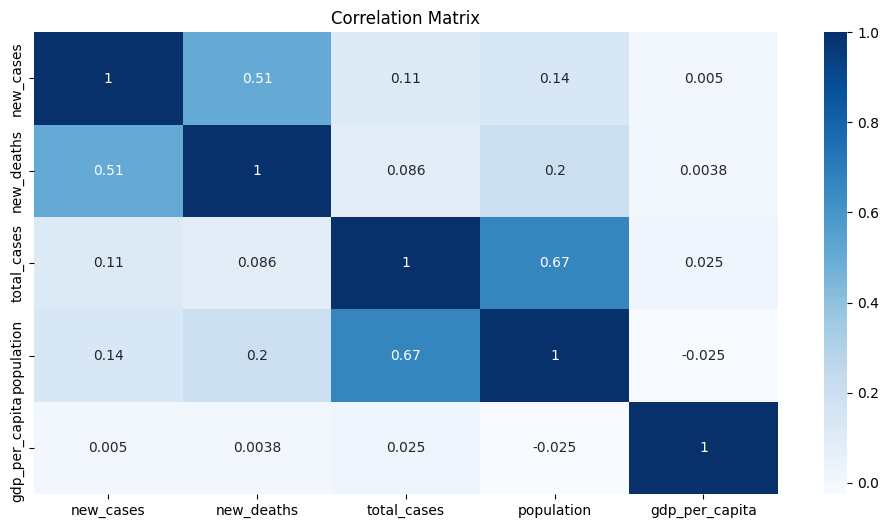

In [18]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [19]:
# Task 4

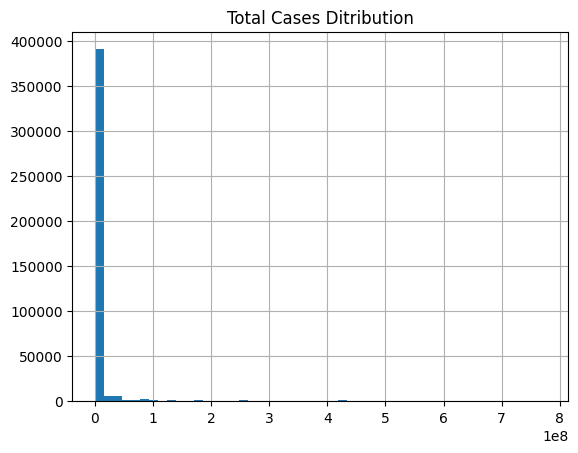

In [20]:
df['total_cases'].hist(bins=50)
plt.title('Total Cases Ditribution')
plt.show()

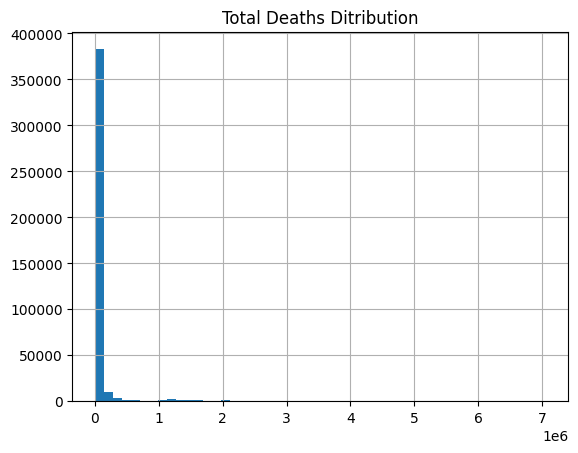

In [21]:
df['total_deaths'].hist(bins=50)
plt.title('Total Deaths Ditribution')
plt.show()

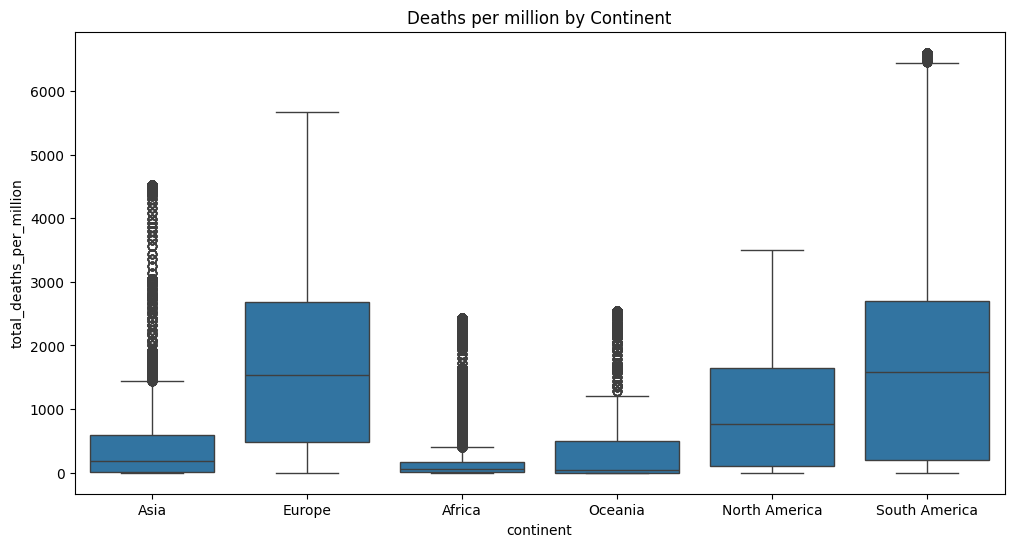

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='continent', y='total_deaths_per_million', data=df)
plt.title('Deaths per million by Continent')
plt.show()

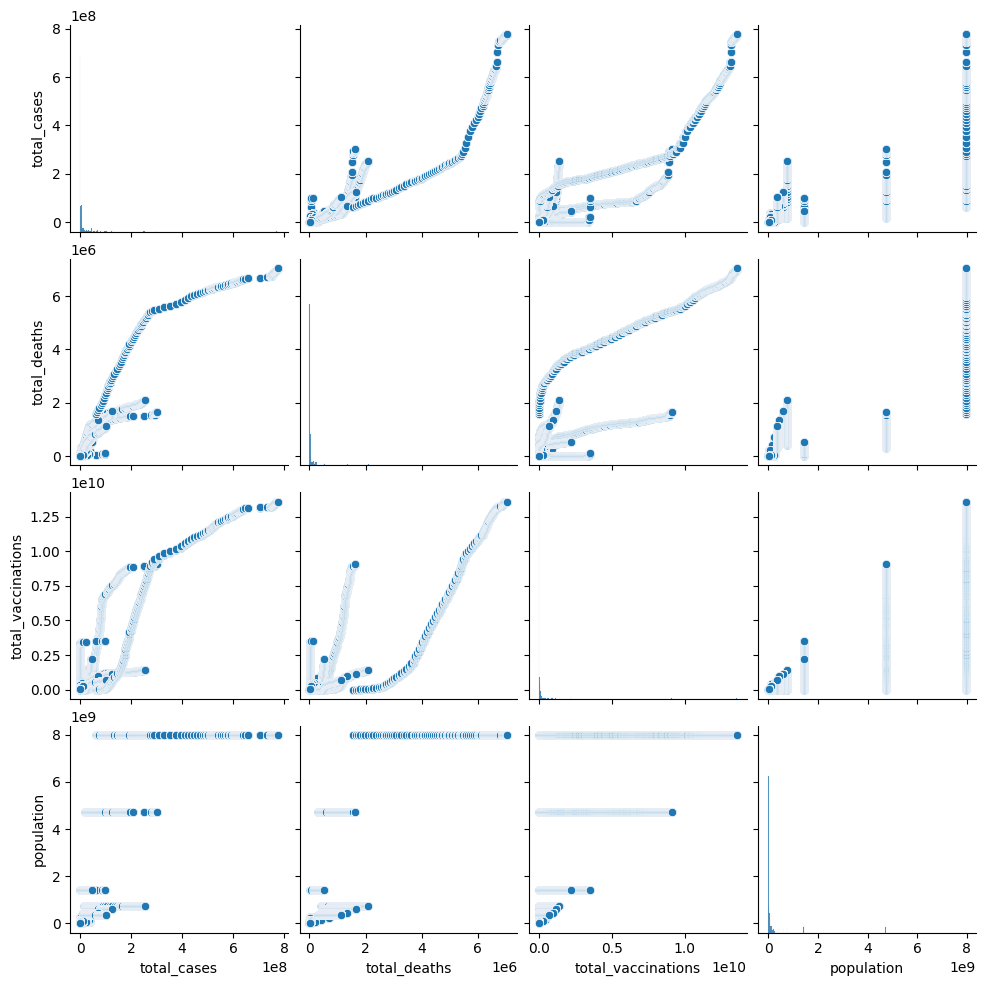

In [23]:
sns.pairplot(df[['total_cases', 'total_deaths', 'total_vaccinations', 'population']].dropna())
plt.show()

In [24]:
# Task 5

In [25]:
countries_iso = ['USA', 'UKR', 'DEU']
df_countries_iso = df[df['iso_code'].isin(countries_iso)]

In [26]:
df_countries_iso['iso_code'].value_counts()

iso_code
DEU    1674
UKR    1674
USA    1674
Name: count, dtype: int64

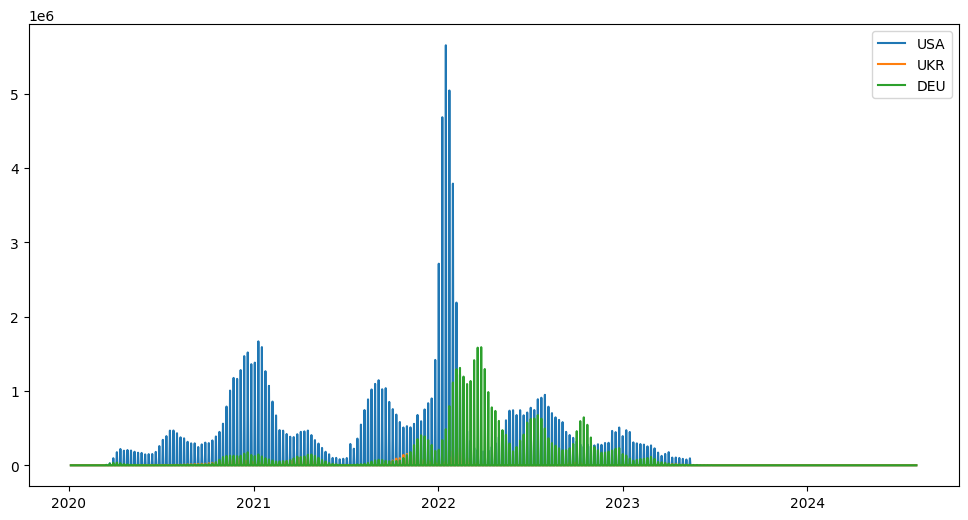

In [27]:
plt.figure(figsize=(12, 6))
for country in countries_iso:
    subset = df_countries_iso[df_countries_iso['iso_code'] == country]
    plt.plot(subset['date'], subset['new_cases'], label=country)

plt.legend()
plt.show()

In [28]:
for country in countries_iso:
    subset = df[df['iso_code'] == country]

    max_cases_data = subset.loc[subset['new_cases'].idxmax(), 'date']
    min_cases_data = subset.loc[subset['new_cases'].idxmin(), 'date']

    print(f'{country}')
    print(f'Max: {max_cases_data}')
    print(f'Min: {min_cases_data}')
    print()

USA
Max: 2022-01-16 00:00:00
Min: 2020-01-05 00:00:00

UKR
Max: 2022-02-06 00:00:00
Min: 2020-01-05 00:00:00

DEU
Max: 2022-03-27 00:00:00
Min: 2020-01-06 00:00:00



In [29]:
# Homework

In [30]:
import plotly.express as px
import plotly.graph_objects as go

In [31]:
countries_5 = ['USA', 'UKR', 'DEU', 'FRA', 'ITA']
df_vacc = df[df['iso_code'].isin(countries_5)][['date', 'iso_code', 'total_vaccinations']].dropna()

In [32]:
fig = go.Figure()

for country in countries_5:
    subset = df_vacc[df_vacc['iso_code'] == country]
    fig.add_trace(go.Scatter(x=subset['date'], y=subset['total_vaccinations'], 
                             mode='lines', name=country))

fig.update_layout(title='Vaccination Dynamics', xaxis_title='Date', yaxis_title='Total Vaccinations')
fig.show()